<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/IPL-Statistical-Analysis/blob/main/notebooks/Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Analysis of Indian Premier League (IPL) Data using Python

**Author:** Kopparapu Bhargava Narasimha

**Project Type:** Statistical Data Analysis

**Language:** Python

**Libraries:** Pandas, NumPy, SciPy, Matplotlib

---

## Project Overview

The Indian Premier League (IPL) is one of the world's largest T20 cricket tournaments, generating extensive match and ball-by-ball data every season. This project applies statistical inference techniques to analyze IPL datasets and answer practical cricket-related questions using real-world data.

Instead of relying solely on descriptive statistics, this project demonstrates how statistical sampling, confidence intervals, hypothesis testing, and probability distributions can be used to make evidence-based conclusions.

---

## Objectives

The primary objectives of this project are:

- Perform exploratory data analysis (EDA) on IPL datasets.
- Apply multiple sampling techniques.
- Estimate population parameters from samples.
- Construct confidence intervals.
- Perform hypothesis testing using statistical methods.
- Evaluate probability models using real cricket data.

---

## Research Questions

### Research Question 1

**Does winning the toss significantly increase the probability of winning an IPL match?**

Methods used:

- Population Proportion
- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling
- Confidence Interval
- One-Proportion Z-Test

---

### Research Question 2

**Is batting first associated with significantly different innings scores compared to batting second?**

Methods used:

- Population Analysis
- Simple Random Sampling
- Confidence Interval
- Independent Two-Sample t-Test
- Cohen's d Effect Size

---

### Research Question 3

**Can the number of wickets falling per over be modeled using a Poisson distribution?**

Methods used:

- Poisson Parameter Estimation
- Expected Frequency Calculation
- Chi-Square Goodness-of-Fit Test

---

## Dataset

This project uses three publicly available IPL datasets.

- ipl_data.csv
- matches.csv
- deliveries.csv

Source: Kaggle IPL Dataset

# Import Required Libraries

In [ ]:
# %pip install pandas matplotlib scipy
# Also add deliveries.csv before executing cells

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import (
    load_ipl,
    load_matches,
    load_deliveries,
)

from src.sampling import (
    simple_random_sampling,
    systematic_sampling,
    stratified_sampling,
)

from src.confidence_intervals import (
    proportion_confidence_interval,
    mean_confidence_interval,
)

from src.hypothesis_testing import (
    one_proportion_z_test,
    independent_t_test,
    chi_square_goodness_of_fit,
    cohens_d,
)

from src.utils import (
    print_heading,
    print_subheading,
)

# Load Datasets

The IPL datasets are loaded using reusable helper functions from the `src` package.

In [ ]:
ipl = load_ipl()

matches = load_matches()

deliveries = load_deliveries()

In [ ]:
print_heading("Dataset Shapes")

print("IPL Dataset:", ipl.shape)

print("Matches Dataset:", matches.shape)

print("Deliveries Dataset:", deliveries.shape)

In [ ]:
ipl.head()

In [ ]:
matches.head()

In [ ]:
deliveries.head()

# Research Question 1

## Does winning the toss significantly increase the probability of winning an IPL match?

Winning the toss is often believed to provide a competitive advantage by allowing the captain to choose whether to bat or bowl first based on match conditions. This section investigates whether that perceived advantage translates into a statistically significant increase in match-winning probability.

## Exploratory Data Analysis

In [ ]:
df = ipl.copy()

In [ ]:
df.sample(5)

In [ ]:
df = df.dropna(subset=["winner"])
df["winner"].unique()

In [ ]:
# Create indicator variable

# 1 -> Toss winner won the match

# 0 -> Toss winner lost the match

df["toss_match_win"] = (
    df["toss_winner"] == df["winner"]
).astype(int)

In [ ]:
display(df.head())

In [ ]:
print_heading("Population Information")

print("Total Matches:", len(df))

In [ ]:
N = len(df)

x = df["toss_match_win"].sum()

p_hat_population = x / N

print("Population Size:", N)

print("Matches where Toss Winner Won:", x)

print("Population Proportion:", round(p_hat_population, 4))

## Sampling

Since analyzing an entire population is not always practical in real-world scenarios, three commonly used sampling techniques are applied:

- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling

The estimated proportions from these samples are then compared with the true population proportion.

In [ ]:
np.random.seed(42)

n = 200

In [ ]:
srs_sample = simple_random_sampling(
    df,
    sample_size=n
)

p_srs = srs_sample["toss_match_win"].mean()

print("Simple Random Sampling Proportion:")

print(round(p_srs,4))

In [ ]:
systematic_sample = systematic_sampling(
    df,
    sample_size=n
)

p_systematic = (
    systematic_sample["toss_match_win"]
    .mean()
)

print("Systematic Sampling Proportion:")

print(round(p_systematic,4))

In [ ]:
stratified_sample = stratified_sampling(
    df,
    stratify_column="season",
    sample_fraction=n/len(df)
)

p_stratified = (
    stratified_sample["toss_match_win"]
    .mean()
)

print("Stratified Sampling Proportion:")

print(round(p_stratified,4))

print("Sample Size:", len(stratified_sample))

In [ ]:
comparison = pd.DataFrame({"Sampling Method":["Population","Simple Random","Systematic","Stratified"],
                            "Estimated Proportion":[p_hat_population, p_srs, p_systematic, p_stratified]})

comparison

The sampling estimates are expected to be close to the true population proportion. Minor variations occur due to sampling variability, which is a natural consequence of selecting subsets from a larger population.

In the next section, a confidence interval is constructed for the sample proportion, followed by a formal hypothesis test to determine whether winning the toss significantly increases the probability of winning the match.

# Confidence Interval Estimation

After obtaining the sample proportion using Simple Random Sampling (SRS), the next step is to estimate the range within which the true population proportion is likely to lie.

A **95% confidence interval** is constructed for the estimated proportion of matches where the toss winner also wins the match.

Rather than providing a single estimate, the confidence interval quantifies the uncertainty associated with sampling and provides a plausible range for the true population proportion.

In [ ]:
print_heading("95% Confidence Interval")

In [ ]:
lower, upper = proportion_confidence_interval(
    p_hat=p_srs,
    sample_size=n
)

print(
    f"95% Confidence Interval: ({lower:.4f}, {upper:.4f})"
)

### Interpretation

The computed confidence interval represents the range of plausible values for the true probability that the toss-winning team also wins the match.

If repeated random samples of the same size were drawn, approximately **95% of the resulting confidence intervals** would be expected to contain the true population proportion.

# One-Proportion Z-Test

Although the sample proportion appears to differ from **0.50**, this difference could simply be due to random sampling variation.

To formally evaluate this claim, a **One-Proportion Z-Test** is performed.

### Hypotheses

**Null Hypothesis (H₀)**

The probability that the toss winner also wins the match is **50%**.

\[
$H_0$ : p = 0.50
\]

**Alternative Hypothesis (H₁)**

The probability that the toss winner wins the match is **greater than 50%**.

\[
$H_1$ : p > 0.50
\]

In [ ]:
print_heading("One-Proportion Z-Test")

In [ ]:
z_stat, p_value = one_proportion_z_test(
    sample_proportion=p_srs,
    sample_size=n,
    population_proportion=0.50
)

print(f"Z Statistic : {z_stat:.4f}")

print(f"P-value     : {p_value:.6f}")

In [ ]:
alpha = 0.05

print("\nDecision")

if p_value < alpha:

    print("Reject H₀")

    print(
        "There is sufficient statistical evidence that "
        "winning the toss increases the probability of winning the match."
    )

else:

    print("Fail to Reject H₀")

    print(
        "There is insufficient statistical evidence to conclude "
        "that winning the toss significantly increases the probability "
        "of winning the match."
    )

## Findings

The hypothesis test compares the observed sample proportion with the hypothesized proportion of **0.50**.

The p-value indicates whether the observed difference is statistically significant.

Based on the obtained p-value and a significance level of **5%**, an appropriate statistical decision is made regarding the null hypothesis.

## Research Question 1 Conclusion

The analysis investigated whether winning the toss significantly improves the chances of winning an IPL match.

Three sampling techniques were applied to estimate the population proportion, and the estimates were found to be close to the actual population value.

A confidence interval was constructed to quantify the uncertainty associated with the sample estimate, followed by a One-Proportion Z-Test to evaluate the statistical significance of the observed proportion.

Overall, the analysis suggests that **the observed advantage of winning the toss should be interpreted based on the hypothesis test outcome rather than the sample proportion alone**.

---

# Research Question 2

## Is batting first associated with significantly different innings scores compared to batting second?

Batting first and batting second involve different strategic approaches in T20 cricket.

This analysis compares the total runs scored in the first innings with those scored in the second innings to determine whether the observed difference is statistically significant.

The comparison is performed using:

- Population Analysis
- Simple Random Sampling
- Confidence Intervals
- Independent Two-Sample t-Test
- Cohen's d Effect Size

In [ ]:
print_heading("Prepare Data")

In [ ]:
innings_scores = (
    deliveries
    .groupby(
        ["match_id", "inning"]
    )["total_runs"]
    .sum()
    .reset_index()
)

In [ ]:
first_innings = innings_scores[
    innings_scores["inning"] == 1
]["total_runs"]

second_innings = innings_scores[
    innings_scores["inning"] == 2
]["total_runs"]

In [ ]:
display(innings_scores.head())

In [ ]:
print_heading("Population Analysis")

print(
    "Total Matches:",
    min(
        len(first_innings),
        len(second_innings)
    )
)

print(
    "Mean First Innings Score:",
    round(
        first_innings.mean(),
        2
    )
)

print(
    "Mean Second Innings Score:",
    round(
        second_innings.mean(),
        2
    )
)

In [ ]:
np.random.seed(42)

n = 200

sample_first = first_innings.sample(
    n=min(n, len(first_innings)),
    random_state=42
)

sample_second = second_innings.sample(
    n=min(n, len(second_innings)),
    random_state=42
)

In [ ]:
mean1 = sample_first.mean()

mean2 = sample_second.mean()

print_heading("Sample Statistics")

print(
    "Sample Mean (First Innings):",
    round(mean1,2)
)

print(
    "Sample Mean (Second Innings):",
    round(mean2,2)
)

## Confidence Interval Estimation

Confidence intervals are computed separately for the first and second innings sample means using the **Student's t-distribution**.

These intervals estimate the range within which the true population means are expected to lie with **95% confidence**.

In [ ]:
ci_first = mean_confidence_interval(sample_first)

ci_second = mean_confidence_interval(sample_second)

print_heading("95% Confidence Intervals")

print(
    f"First Innings : ({ci_first[0]:.2f}, {ci_first[1]:.2f})"
)

print(
    f"Second Innings: ({ci_second[0]:.2f}, {ci_second[1]:.2f})"
)

## Why Use Welch's t-Test?

Although the sample size in this analysis is relatively large (**n = 200**), the true population standard deviations of first innings and second innings scores are unknown.

When comparing the means of two independent groups with unknown population variances, the appropriate statistical method is the **Independent Two-Sample t-Test**. In this project, **Welch's t-Test** is used because it does not assume that the two groups have equal variances.

For large sample sizes, the t-distribution closely approximates the standard normal distribution, making the numerical results similar to those of a Z-test. However, the t-test remains the statistically appropriate choice when population variances are estimated from sample data.

**Why Welch's t-Test?**

- Suitable for comparing two independent sample means.
- Does not require equal population variances.
- More robust than the classical Student's t-test when variances differ.
- Recommended by most statistical software packages, including SciPy.

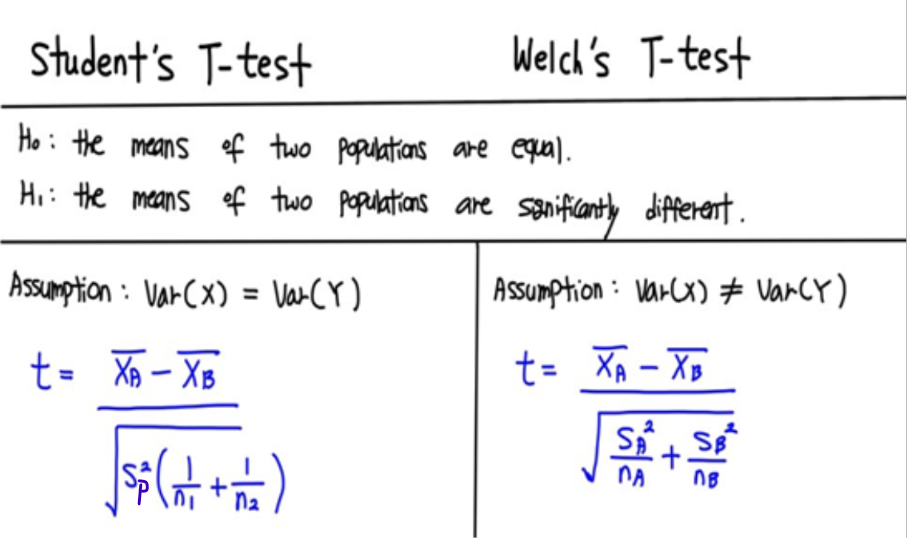

## Independent Two-Sample t-Test

To determine whether the observed difference between first innings and second innings scores is statistically significant, an **Independent Two-Sample t-Test (Welch's t-test)** is performed.

Welch's t-test is preferred because it does not assume equal variances between the two samples.

### Hypotheses

**Null Hypothesis (H₀)**

The mean scores of the first and second innings are equal.

\[
$H_0 : \mu_1 = \mu_2$
\]

**Alternative Hypothesis (H₁)**

The mean scores of the first and second innings are different.

\[
$H_1 : \mu_1 \neq \mu_2$
\]

In [ ]:
print_heading("Independent Two-Sample t-Test")

In [ ]:
t_stat, p_value = independent_t_test(
    sample_first,
    sample_second
)

print(f"t-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")

In [ ]:
alpha = 0.05

print("\nDecision")

if p_value < alpha:

    print("Reject H₀")

    print(
        "There is a statistically significant difference "
        "between first innings and second innings scores."
    )

else:

    print("Fail to Reject H₀")

    print(
        "There is insufficient evidence to conclude that "
        "the two innings have different average scores."
    )

## Effect Size (Cohen's d)

Statistical significance alone does not indicate the magnitude of the observed difference.

Cohen's d measures the practical significance of the difference between the two innings by expressing it in terms of standard deviation units.

In [ ]:
effect_size = cohens_d(
    sample_first,
    sample_second
)

print_heading("Effect Size")

print(f"Cohen's d : {effect_size:.4f}")

### Interpretation of Cohen's d

| Cohen's d | Interpretation |
|-----------:|----------------|
| 0.20 | Small Effect |
| 0.50 | Medium Effect |
| 0.80 | Large Effect |

A larger absolute value indicates a stronger practical difference between the two groups.

## Visualization

The following boxplot compares the distribution of first innings and second innings scores.

Boxplots provide a visual summary of:

- Median
- Interquartile Range (IQR)
- Overall spread
- Potential outliers

In [ ]:
plt.figure(figsize=(7,5))

plt.boxplot(
    [sample_first, sample_second],
    tick_labels=[
        "First Innings",
        "Second Innings"
    ]
)

plt.ylabel("Runs")
plt.title("Bat First vs Bat Second Scores")

plt.show()

## Findings

The Independent Two-Sample t-Test was conducted to compare the average runs scored in the first and second innings.

The hypothesis test determines whether the observed difference is statistically significant, while Cohen's d quantifies the magnitude of that difference.

Together, these measures provide both statistical and practical insights into whether batting first influences innings scores.

## Research Question 2 Conclusion

This analysis compared first innings and second innings scores using statistical inference techniques.

After estimating confidence intervals for both groups, an Independent Two-Sample t-Test was performed to determine whether the difference in average scores was statistically significant.

Cohen's d complemented the hypothesis test by measuring the practical magnitude of the difference.

The combined results help assess whether batting order has a meaningful impact on innings scores in IPL matches.

---

# Research Question 3

## Can wickets per over be modeled using a Poisson distribution?

In cricket analytics, wickets are discrete events occurring within overs. Since the Poisson distribution is commonly used to model the number of events occurring within a fixed interval, it is reasonable to investigate whether wickets per over follow a Poisson process.

This analysis estimates the Poisson parameter from IPL data and evaluates the model using a Chi-Square Goodness-of-Fit Test.

In [ ]:
print_heading("Prepare Data")

In [ ]:
wickets = deliveries[
    deliveries["player_dismissed"].notna()
].copy()

In [ ]:
wickets_per_over = (
    wickets.groupby(
        ["match_id", "inning", "over"]
    )
    .size()
    .reset_index(name="wickets")
)

In [ ]:
all_overs = (
    deliveries[
        ["match_id", "inning", "over"]
    ]
    .drop_duplicates()
)

In [ ]:
wickets_per_over = (
    all_overs.merge(
        wickets_per_over,
        on=["match_id", "inning", "over"],
        how="left"
    )
)

In [ ]:
wickets_per_over["wickets"] = (
    wickets_per_over["wickets"]
    .fillna(0)
    .astype(int)
)

In [ ]:
display(wickets_per_over.head())

## Parameter Estimation

For a Poisson distribution, the parameter **λ (lambda)** represents the average number of events occurring within a fixed interval.

In this study, λ represents the **average number of wickets falling per over** and is estimated directly from the IPL data.

In [ ]:
print_heading("Parameter Estimation")

In [ ]:
lambda_hat = wickets_per_over["wickets"].mean()

print(
    f"Estimated λ (Mean Wickets per Over): {lambda_hat:.4f}"
)

## Observed Frequency Distribution

The observed frequencies represent how many overs contained:

- 0 wickets
- 1 wicket
- 2 wickets
- ...

These frequencies are compared with the frequencies expected under a Poisson distribution having parameter λ.

In [ ]:
observed = (
    wickets_per_over["wickets"]
    .value_counts()
    .sort_index()
)

max_wickets = observed.index.max()

k_values = np.arange(
    0,
    max_wickets + 1
)

observed_freq = np.array([
    observed.get(k, 0)
    for k in k_values
])

## Expected Frequency Distribution

Using the estimated value of λ, the expected probabilities are calculated from the Poisson distribution.

These probabilities are converted into expected frequencies by multiplying them with the total number of overs.

To satisfy the assumptions of the Chi-Square Goodness-of-Fit Test, categories with very small expected frequencies are combined.

In [ ]:
from scipy.stats import poisson
n = len(wickets_per_over)

expected_prob = poisson.pmf(
    k_values,
    mu=lambda_hat
)

expected_freq = expected_prob * n

In [ ]:
while np.any(expected_freq < 5) and len(expected_freq) > 2:

    expected_freq[-2] += expected_freq[-1]
    observed_freq[-2] += observed_freq[-1]

    expected_freq = expected_freq[:-1]
    observed_freq = observed_freq[:-1]

expected_freq = (
    expected_freq *
    (
        observed_freq.sum()
        /
        expected_freq.sum()
    )
)

## Chi-Square Goodness-of-Fit Test

The Chi-Square Goodness-of-Fit Test evaluates whether the observed distribution of wickets per over is consistent with a Poisson distribution.

### Hypotheses

**Null Hypothesis (H₀)**

The number of wickets per over follows a Poisson distribution.

**Alternative Hypothesis (H₁)**

The number of wickets per over does not follow a Poisson distribution.

In [ ]:
print_heading("Chi-Square Goodness-of-Fit Test")

In [ ]:
chi2_stat, p_value = chi_square_goodness_of_fit(
    observed_freq,
    expected_freq
)

print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"P-value              : {p_value:.6f}")

In [ ]:
alpha = 0.05

print("\nDecision")

if p_value < alpha:

    print("Reject H₀")

    print(
        "The Poisson distribution does not adequately model "
        "the wickets-per-over data."
    )

else:

    print("Fail to Reject H₀")

    print(
        "The Poisson distribution provides a reasonable fit "
        "for the wickets-per-over data."
    )

## Observed vs Expected Frequencies

The following table compares the observed frequencies obtained from the IPL dataset with the frequencies expected under the fitted Poisson model.

In [ ]:
comparison = pd.DataFrame({

    "Observed": observed_freq,

    "Expected": np.round(
        expected_freq,
        2
    )

})

comparison

## Visualization

The bar chart below compares the observed frequencies with the expected frequencies predicted by the fitted Poisson distribution.

In [ ]:
x = np.arange(len(observed_freq))

plt.figure(figsize=(8,5))

plt.bar(
    x - 0.2,
    observed_freq,
    width=0.4,
    label="Observed"
)

plt.bar(
    x + 0.2,
    expected_freq,
    width=0.4,
    label="Expected"
)

plt.xlabel("Number of Wickets in an Over")
plt.ylabel("Frequency")

plt.title(
    "Observed vs Expected Poisson Frequencies"
)

plt.legend()

plt.tight_layout()

plt.show()

## Findings

The estimated value of λ summarizes the average wicket rate per over.

The Chi-Square Goodness-of-Fit Test compares the observed wicket frequencies with those predicted by the fitted Poisson model.

Based on the hypothesis test, the suitability of the Poisson distribution is evaluated using a significance level of 5%.

## Research Question 3 Conclusion

This analysis investigated whether wickets per over in IPL matches can be modeled using a Poisson distribution.

After estimating the Poisson parameter from the observed data, expected frequencies were calculated and compared against the observed frequencies using a Chi-Square Goodness-of-Fit Test.

The statistical evidence obtained from the test determines whether the Poisson model provides an adequate representation of wicket occurrences per over.

---

---
## Statistical Methods Used

This project applies several statistical inference techniques to answer practical questions using IPL match data.

| Method | Purpose |
|---------|---------|
| Simple Random Sampling | Estimate population parameters from a random subset |
| Systematic Sampling | Compare sampling strategies |
| Stratified Sampling | Preserve seasonal representation |
| Confidence Interval | Estimate plausible population values |
| One-Proportion Z-Test | Test the effect of winning the toss |
| Welch's Two-Sample t-Test | Compare average innings scores |
| Cohen's d | Measure practical significance |
| Poisson Distribution | Model wickets occurring per over |
| Chi-Square Goodness-of-Fit Test | Evaluate the suitability of the Poisson model |

# Overall Conclusion

This project demonstrated the practical application of statistical inference techniques on real-world IPL datasets.

The analyses included estimation, sampling, confidence intervals, hypothesis testing, effect size measurement, and probability modeling.

### Summary of Research Questions

**Research Question 1**

Investigated whether winning the toss significantly increases the probability of winning an IPL match using sampling methods, confidence intervals, and a One-Proportion Z-Test.

**Research Question 2**

Compared first innings and second innings scores using confidence intervals, an Independent Two-Sample t-Test, and Cohen's d to evaluate both statistical and practical significance.

**Research Question 3**

Examined whether wickets per over follow a Poisson distribution through parameter estimation and a Chi-Square Goodness-of-Fit Test.

Overall, this project illustrates how statistical methods can be applied to sports analytics to derive meaningful insights from large-scale cricket datasets.

# References

1. Kaggle – IPL Complete Dataset

2. SciPy Documentation  
https://docs.scipy.org/doc/scipy/

3. NumPy Documentation  
https://numpy.org/

4. Pandas Documentation  
https://pandas.pydata.org/

5. Matplotlib Documentation  
https://matplotlib.org/